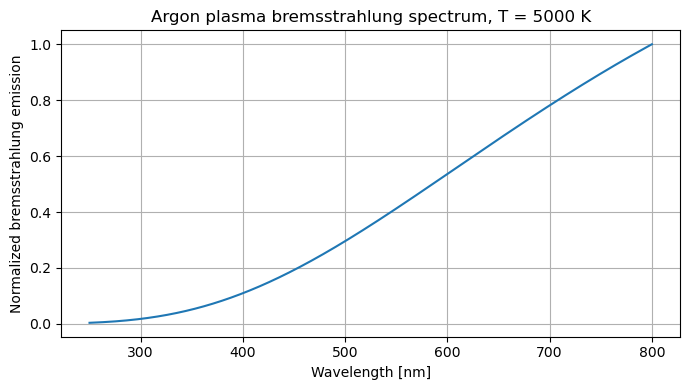

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Physical constants
h = 6.62607015e-34       # J.s
c = 2.99792458e8        # m/s
kB = 1.380649e-23       # J/K

# Plasma parameters
T = 5000                # electron temperature [K]
Z = 1                   # Ar+ approximation
ne = 1e20               # electron density [m^-3]
ni = ne / Z             # ion density [m^-3]
gff = 1.0               # Gaunt factor ~ 1

# Wavelength range
lambda_nm = np.linspace(250, 800, 1000)   # nm
lambda_m = lambda_nm * 1e-9               # m

# Frequency
nu = c / lambda_m

# Bremsstrahlung spectral emissivity per Hz
# Approximate SI scaling, arbitrary normalization acceptable for spectrum shape
epsilon_nu = (
    Z**2 * ne * ni
    * T**(-0.5)
    * np.exp(-h * nu / (kB * T))
    * gff
)

# Convert from per Hz to per wavelength
# epsilon_lambda = epsilon_nu * |dnu/dlambda| = epsilon_nu * c/lambda^2
epsilon_lambda = epsilon_nu * c / lambda_m**2

# Normalize for easier plotting
epsilon_lambda_norm = epsilon_lambda / np.max(epsilon_lambda)

# Plot
plt.figure(figsize=(7, 4))
plt.plot(lambda_nm, epsilon_lambda_norm)
plt.xlabel("Wavelength [nm]")
plt.ylabel("Normalized bremsstrahlung emission")
plt.title("Argon plasma bremsstrahlung spectrum, T = 5000 K")
plt.grid(True)
plt.tight_layout()
plt.show()